In [91]:
import requests
from bs4 import BeautifulSoup as bs
import json

In [110]:
response = requests.get("https://jsonplaceholder.typicode.com/users")

# 역직렬화

In [111]:
# .loads() : json -> python 객체

datas = json.loads(response.text)

# 직렬화

In [112]:
# .dumps() : python 객체 -> json

datas = json.dumps(datas)

In [113]:
url = "https://www.melon.com/chart/index.htm"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"}


In [114]:
# BeautifulSoup : html parser

soup = bs(response.text, "html.parser")

In [115]:
# 선택자 선택이 가능

soup.find("span", class_ = "hour")

In [116]:
soup.select_one("span.hour")

In [117]:
# .text: 태그의 내용

soup.select_one("span.hour").text

AttributeError: 'NoneType' object has no attribute 'text'

In [83]:
song_list = soup.select("tbody tr")

In [84]:
print(song_list)

[]


In [85]:
song_td = song_list[1].select("td")[5]

song_title = song_td.select("a")[0].text
song_singer = song_td.select("a")[1].text

IndexError: list index out of range

In [42]:
print(song_title)
print(song_singer)

기쁨, 슬픔, 아름다운 마음
AKMU (악뮤)


In [97]:
song_datas = []

for i, tag in enumerate(song_list):
    song_td = tag.select("td")[5]
    
    song_title = song_td.select("a")[0].text
    singer = song_td.select("a")[1].text

    song_datas.append((str((i + 1)) + "위", song_title, singer))

In [98]:
song_datas

[]

In [52]:
import csv
import os

In [54]:
# r"": 경로 이슈 해결!

folder_path = r"C:\back_0900_lgh\python\resource\csv"
file_name = "melon.csv"

file_path = os.path.join(folder_path, file_name)
print(file_path)

C:\back_0900_lgh\python\resource\csv\melon.csv


In [57]:
with open(file_path,"w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)

    writer.writerow(["순위","제목","가수"])
    writer.writerows(song_datas)

In [119]:
response = requests.get(url)

In [146]:
url = "https://finance.naver.com/sise/lastsearch2.naver"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"}

In [147]:
soup = bs(response.text, "html.parser")

In [149]:
soup.text

'\n\n\nNpay 증권\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n메인 메뉴로 바로가기\n본문으로 바로가기\n\n\n\n\n\n\n\n\n\n\n네이버\n\n\n\n\n\n페이\n\n\n\n\n\n\n증권\n\n\n\n\n\n\n증권 종목명·지수명 검색\n\n\n\n\n\n\n\n검색\n\n\n자동완성\n\n\n\n\n\n\n\n@code@\n@txt@\n@market@\n\n@full_txt@\n@in_code@\n@in_name@\n@in_link@\n@in_market@\n\n\n\n\n\t\t\t\t\t\t\t\t\t\t\t\t공모주와 해외 종목은 모바일 페이지로 이동합니다.\n\t\t\t\t\t\t\t\t\t\t\t\n\n\n\n\n\n\n\n\n\t\t\t\t\t\t\t\t\t\t\t\t현재 자동완성 기능을 사용하고 계십니다.\n\t\t\t\t\t\t\t\t\t\t\t\n\n\n\n\n\n\n\n\n\n\t\t\t\t\t\t\t\t\t\t\t\t자동완성 기능이 활성화되었습니다.\n\t\t\t\t\t\t\t\t\t\t\t\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n증권 홈\n국내증시선택됨\n해외증시\n시장지표\n리서치\n뉴스\nMY\n\n\n\n\n\n\t\t\t\t\t\t새로운 증권 보기\n\t\t\t\t\t\t\nNEW\n\n\n\n\t\t\t\t\t\t더 편리해진 증권을 만나보세요\n\t\t\t\t\t\t\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n국내증시\n\nKRX 주요시세\n\n코스피\n코스닥\n선물\n코스피100\n코스피200\n코리아밸류업\n코넥스\n시가총액\n배당\n업종\n테마\n그룹사\nETF\nETN\n상승\n보합\n하락\n상한가\n하한가\n급등\n급락\n거래상위\n급증\n급감\n투자자별매매동향\n외국인매매\n기관매매\n프로그램매매동향\n증시자금동향\n신규상장\n외국인보유\n장외시세\nIPO\n\n\nNXT

In [151]:
stock_div = soup.select("div")[2]

In [152]:
stock_div.text

'\n\n\n\n\n\n\n\n네이버\n\n\n\n\n\n페이\n\n\n\n\n\n\n증권\n\n\n\n\n\n\n증권 종목명·지수명 검색\n\n\n\n\n\n\n\n검색\n\n\n자동완성\n\n\n\n\n\n\n\n@code@\n@txt@\n@market@\n\n@full_txt@\n@in_code@\n@in_name@\n@in_link@\n@in_market@\n\n\n\n\n\t\t\t\t\t\t\t\t\t\t\t\t공모주와 해외 종목은 모바일 페이지로 이동합니다.\n\t\t\t\t\t\t\t\t\t\t\t\n\n\n\n\n\n\n\n\n\t\t\t\t\t\t\t\t\t\t\t\t현재 자동완성 기능을 사용하고 계십니다.\n\t\t\t\t\t\t\t\t\t\t\t\n\n\n\n\n\n\n\n\n\n\t\t\t\t\t\t\t\t\t\t\t\t자동완성 기능이 활성화되었습니다.\n\t\t\t\t\t\t\t\t\t\t\t\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'

In [153]:
stock_newarea = stock_div.select("div")[1]

In [154]:
stock_newarea.text

'\n\n\n\n\n\n네이버\n\n\n\n\n\n페이\n\n\n\n\n\n\n증권\n\n\n'

# 셀레니움(Selenium)
- 셀레니움(Selenium)은 웹 브라우저를 자동으로 제어할 수 있는 오픈소스 툴로
웹 애플리케이션을 테스트하거나 크롤링하기 위해 사용되는 브라우저 자동화 도구이다.
Chrome, Firefox, Edge 등 여러가지 브라우저에서 작업이 가능하며,
동작하지 않는 브라우저도 존재하며, 로그인, 폼 제출, 버튼 클릭 등 작업을
자동화 할 수 있다

In [158]:
!pip install selenium

In [165]:
import selenium
from selenium.webdriver import Chrome # 크롬 자동화 도구
from selenium.webdriver.common.keys import Keys # 자동화 도구 키 제어
from selenium.webdriver.common.by import By

In [163]:
driver = Chrome()

url = "https://www.google.com/"
driver.get(url)

In [166]:
# driver.find_element("속성명","속성값")
# search = driver.find_element(By.ID,"gLFyf")
# search = driver.find_element(By.NAME,"gLFyf")
search = driver.find_element(By.CLASS_NAME,"gLFyf")
search.send_keys("고양이")

In [167]:
# 엔터
search.send_keys(Keys.RETURN)

In [169]:
url = "https://comic.naver.com/webtoon/detail?titleId=733074&no=273&week=mon"

In [170]:
import time

In [171]:
time.sleep(2)
print("2초 뒤에 실행")

2초 뒤에 실행


In [172]:
driver.get(url)
time.sleep(2)

soup = bs(driver.page_source)




<html lang="ko"><head>
<meta content="text/html; charset=utf-8" http-equiv="Content-type"/>
<meta content="IE=edge, chrome=1" http-equiv="X-UA-Compatible"/>
<meta content="article" property="og:type"/>
<meta content="네이버 웹툰" property="og:article:author"/>
<meta content="https://comic.naver.com" property="og:article:author:url"/>
<meta content="백수세끼 - 273화 오징어덮밥" property="og:title"/>
<meta content="https://shared-comic.pstatic.net/thumb/webtoon/733074/273/thumbnail_600x315_efb5f0aa-9d58-43e9-bcdb-ffd12f1f3f7a.jpg" property="og:image"/>
<title>백수세끼 - 273화 오징어덮밥 : 네이버 웹툰</title>
<link href="https://shared-comic.pstatic.net/favicon/favicon_96x96.ico" rel="icon" type="image/x-icon"/>
<link href="https://ssl.pstatic.net/static/wcc/kw/prod-1.0/index.css?v=202605111720" rel="stylesheet" type="text/css"/>
<link href="/39293056ef7d8bcbcde7.css" rel="stylesheet"/>
<script>
        if (/MSIE \d|Trident.*rv:/.test(navigator.userAgent)) {
            window.location = 'microsoft-edge:' + window.loc
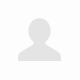
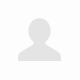
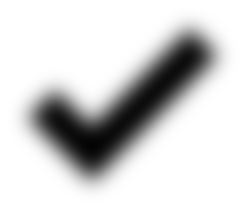

In [173]:
print(soup)

In [174]:
all_reply_button = driver.find_elements(By.CLASS_NAME, "_root_14no7_1")[1]

In [175]:
all_reply_button.click()

In [182]:
more_button = driver.find_element(By.CLASS_NAME, "eE2Vs")

In [184]:
for i in range(5):
    time.sleep(5)
    more_button.click()

In [185]:
def ger_reply():
    try:
        driver = Chrome()
    
        url = "https://comic.naver.com/webtoon/detail?titleId=733074&no=273&week=mon"
        driver.get(url)
    
        time.sleep(3)
        all_reply_button = driver.find_elements(By.CLASS_NAME, "_root_14no7_1")[1]
        all_reply_button.click()
    
        time.sleep(3)
        more_button = driver.find_element(By.CLASS_NAME, "eE2Vs")
        for i in range(5):
            time.sleep(5)
            more_button.click()
            
        soup = bs(driver.page_source)
        return soup    
        
    
    except StaleElementReferenceException:
        soup = bs(driver.page_source)
        return soup

<html lang="ko"><head>
<meta content="text/html; charset=utf-8" http-equiv="Content-type"/>
<meta content="IE=edge, chrome=1" http-equiv="X-UA-Compatible"/>
<meta content="article" property="og:type"/>
<meta content="네이버 웹툰" property="og:article:author"/>
<meta content="https://comic.naver.com" property="og:article:author:url"/>
<meta content="백수세끼 - 273화 오징어덮밥" property="og:title"/>
<meta content="https://shared-comic.pstatic.net/thumb/webtoon/733074/273/thumbnail_600x315_efb5f0aa-9d58-43e9-bcdb-ffd12f1f3f7a.jpg" property="og:image"/>
<title>백수세끼 - 273화 오징어덮밥 : 네이버 웹툰</title>
<link href="https://shared-comic.pstatic.net/favicon/favicon_96x96.ico" rel="icon" type="image/x-icon"/>
<link href="https://ssl.pstatic.net/static/wcc/kw/prod-1.0/index.css?v=202605111740" rel="stylesheet" type="text/css"/>
<link href="/39293056ef7d8bcbcde7.css" rel="stylesheet"/>
<script>
        if (/MSIE \d|Trident.*rv:/.test(navigator.userAgent)) {
            window.location = 'microsoft-edge:' + window.loc
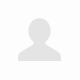
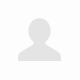
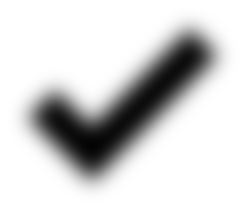
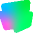
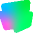
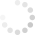

In [186]:
ger_reply()